In [5]:
## Day 13
## Hour 1
## block 1
import pandas as pd
df = pd.read_csv('Telco_Customer_Churn.csv')
df.head()
df.columns
y = df["Churn"]
X = df.drop("Churn", axis=1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT for churn
)

In [6]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(7043, 20)
(5634, 20)
(1409, 20)


In [ ]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


AttributeError: 'Series' object has no attribute 'columns'

In [13]:
## Hour 6

## Block 1
## Target distribution check
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


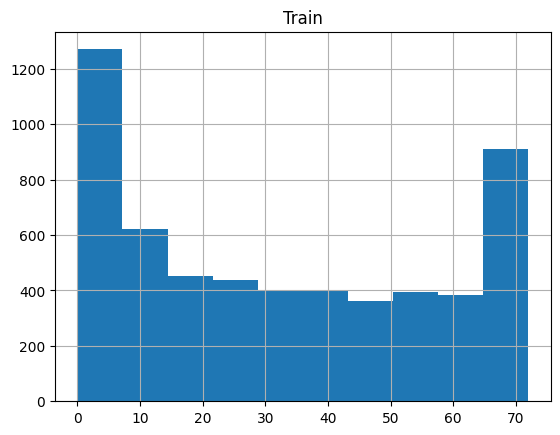

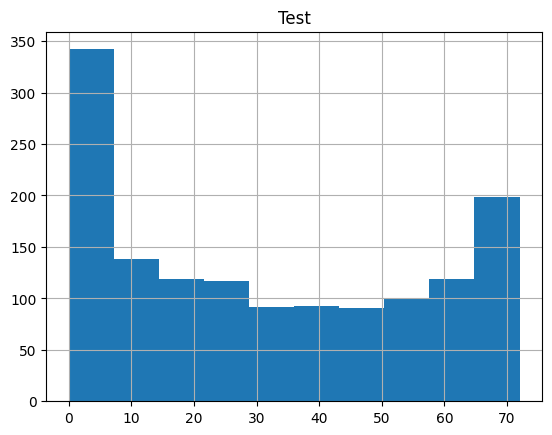

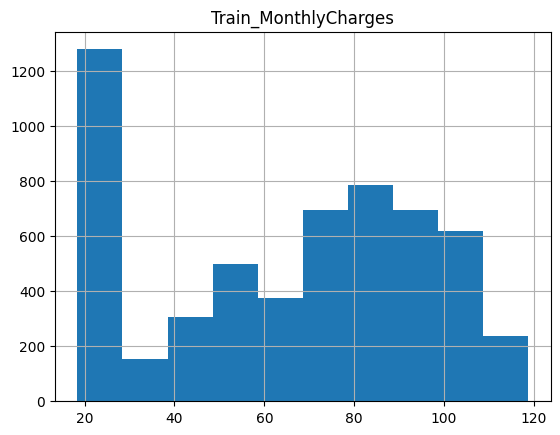

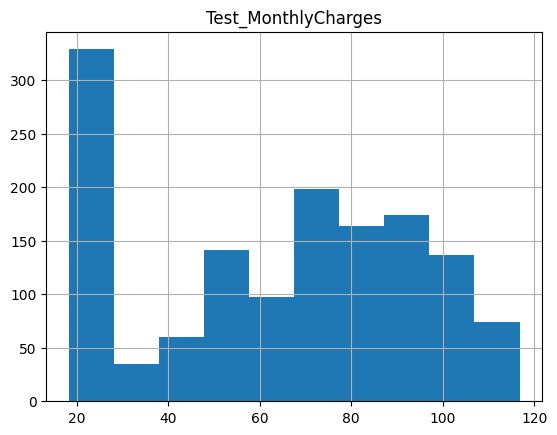

In [ ]:
## Numerical features Disribution
import matplotlib.pyplot as plt

X_train["tenure"].hist()
plt.title("Train")
plt.show()

X_test["tenure"].hist()
plt.title("Test")
plt.show()

## for MonthlyCharges
X_train["MonthlyCharges"].hist()
plt.title("Train_MonthlyCharges")
plt.show()

X_test["MonthlyCharges"].hist()
plt.title("Test_MonthlyCharges")
plt.show()


In [18]:
print(X_train.describe())
print(X_test.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    5634.000000  5634.000000     5634.000000
mean        0.163294    32.485091       64.929961
std         0.369667    24.568744       30.138105
min         0.000000     0.000000       18.400000
25%         0.000000     9.000000       35.662500
50%         0.000000    29.000000       70.500000
75%         0.000000    55.000000       90.000000
max         1.000000    72.000000      118.750000
       SeniorCitizen       tenure  MonthlyCharges
count    1409.000000  1409.000000     1409.000000
mean        0.157559    31.915543       64.088857
std         0.364456    24.525829       29.898290
min         0.000000     0.000000       18.250000
25%         0.000000     8.000000       35.200000
50%         0.000000    28.000000       69.950000
75%         0.000000    55.000000       89.450000
max         1.000000    72.000000      116.800000


In [19]:
## Categorical features distribution
print(X_train["Contract"].value_counts(normalize=True))
print(X_test["Contract"].value_counts(normalize=True))

Contract
Month-to-month    0.550586
Two year          0.241214
One year          0.208200
Name: proportion, dtype: float64
Contract
Month-to-month    0.548616
Two year          0.238467
One year          0.212917
Name: proportion, dtype: float64


In [20]:
## Compare churn distribution
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [25]:
## selecting columns with only numerical features
numerical_cols = [col for col in X_train.columns if X_train[col].dtype in ["int64", "float64"]]
print(numerical_cols)
print(X_train.columns)
X_train.head()

['SeniorCitizen', 'tenure', 'MonthlyCharges']
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7
3810,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [26]:
## Compare Categorical features distribution
train_dist = X_train["Contract"].value_counts(normalize=True)
test_dist = X_test["Contract"].value_counts(normalize=True)

compare = pd.concat([train_dist, test_dist], axis=1)
compare.columns = ["Train", "Test"]

print(compare)

                   Train      Test
Contract                          
Month-to-month  0.550586  0.548616
Two year        0.241214  0.238467
One year        0.208200  0.212917


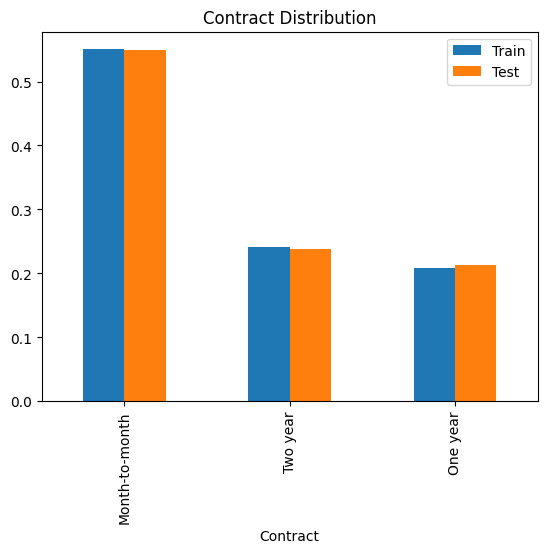

In [27]:
compare.plot(kind="bar")
plt.title("Contract Distribution")
plt.show()

In [ ]:
## Hour 7
## leetCode
nums=[2,7,11,15]
target=9    
output = [0,1]
for i in range(len(nums)):
    for j in range(i+1,len(nums)):
        if nums[i]+nums[j]==target:
            print([i,j])

def two_sum(nums, target):
    seen={}
    for i,num in enumerate(nums):
        if target-num in seen:
            return [seen[target-num],i]
        seen[num]=i
print(two_sum(nums, target))


[0, 1]
[0, 1]
0 2
1 7
2 11
3 15


In [46]:
lst = ["eat","tea","tan","ate","nat","bat"]

# 👉 Output:
# [["eat","tea","ate"], ["tan","nat"], ["bat"]]

def group_anagrams(lst):
    anagram_dict = {}
    for word in lst:
        sorted_word = ''.join(sorted(word))
        if sorted_word in anagram_dict:
            anagram_dict[sorted_word].append(word)
        else:
            anagram_dict[sorted_word] = [word]
    return list(anagram_dict.values())

print(group_anagrams(lst))

[['eat', 'tea', 'ate'], ['tan', 'nat'], ['bat']]


In [ ]:
## hour 8
## Block 1
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.columns)

## Remove useless features
X = X.drop(["customerID"], axis=1)
print(X.columns)

## Block 3
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')
